# 08. 이용목적/차량구분/장애유형별 세분 분석

세그먼트별 접수건수, 취소율, 탑승전환율, 접수→승차 시간을 비교한다.


In [2]:
import json
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from IPython.display import display

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트 설정
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

# 서울 자치구 지도 데이터 로드
map_path = project_root / "data" / "raw" / "seoul_municipalities_geo_simple.json"

with open(map_path, encoding="utf-8") as map_file:
    seoul_map = json.load(map_file)

In [3]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

request_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv"
print(request_path)

usecols = [
    '접수일시', '승차일시', '취소일시',
    '이용목적', '차량구분', '장애유형', '접수시간대', '접수요일'
]

df_segment = pd.read_csv(request_path, usecols=usecols)
for col in ['접수일시', '승차일시', '취소일시']:
    df_segment[col] = pd.to_datetime(df_segment[col], errors='coerce')

df_segment = df_segment[
    (df_segment['접수일시'] >= '2025-01-01') &
    (df_segment['접수일시'] < '2026-01-01')
].copy()

df_segment['취소여부'] = df_segment['취소일시'].notna()
df_segment['탑승여부'] = df_segment['승차일시'].notna()
df_segment['접수_승차_분'] = (df_segment['승차일시'] - df_segment['접수일시']).dt.total_seconds() / 60
df_segment.loc[df_segment['접수_승차_분'] < 0, '접수_승차_분'] = pd.NA

print(f'분석 행 수: {len(df_segment):,}')
for col in ['접수일시', '승차일시', '취소일시']:
    print(f'{col} 결측/변환실패: {df_segment[col].isna().sum():,}건')

df_segment.head()


/Users/blaumonde/calltaxi-DA/data/processed/서울시설공단_장애인콜택시 접수일시_월주차_파생컬럼_20251231.csv
분석 행 수: 1,722,431
접수일시 결측/변환실패: 0건
승차일시 결측/변환실패: 245,339건
취소일시 결측/변환실패: 1,477,156건


,접수일시,승차일시,취소일시,이용목적,차량구분,장애유형,접수시간대,접수요일,취소여부,탑승여부,접수_승차_분
0,2025-01-01 00:01:26.127,2025-01-01 00:49:52.967,NaT,기타,특장차,지체,0,수요일,False,True,48.447333
1,2025-01-01 00:03:10.557,NaT,2025-01-01 00:21:15,기타,특장차,뇌병,0,수요일,True,False,NaN
2,2025-01-01 00:03:31.230,2025-01-01 00:36:18.433,NaT,기타,특장차,뇌병,0,수요일,False,True,32.786717
3,2025-01-01 00:03:40.573,2025-01-01 00:53:48.440,NaT,기타,특장차,지체,0,수요일,False,True,50.131117
4,2025-01-01 00:04:15.077,2025-01-01 00:40:07.840,NaT,기타,특장차,지체,0,수요일,False,True,35.879383


## 세그먼트 요약 함수


In [4]:
def build_segment_summary(column_name, min_count=100):
    summary = (
        df_segment
        .dropna(subset=[column_name])
        .groupby(column_name)
        .agg(
            접수건수=('접수일시', 'size'),
            취소건수=('취소여부', 'sum'),
            탑승건수=('탑승여부', 'sum'),
            평균_접수승차분=('접수_승차_분', 'mean'),
            중앙값_접수승차분=('접수_승차_분', 'median'),
            p90_접수승차분=('접수_승차_분', lambda s: s.quantile(0.9)),
        )
        .reset_index()
    )
    summary['취소율(%)'] = summary['취소건수'] / summary['접수건수'] * 100
    summary['탑승전환율(%)'] = summary['탑승건수'] / summary['접수건수'] * 100
    return summary[summary['접수건수'] >= min_count].sort_values('접수건수', ascending=False).reset_index(drop=True)

purpose_demand_summary = build_segment_summary('이용목적')
vehicle_demand_summary = build_segment_summary('차량구분')
disability_demand_summary = build_segment_summary('장애유형')

segment_demand_summary = {
    '이용목적': purpose_demand_summary,
    '차량구분': vehicle_demand_summary,
    '장애유형': disability_demand_summary,
}

display(purpose_demand_summary)
display(vehicle_demand_summary)
display(disability_demand_summary)


,이용목적,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
0,기타,1338521,184484,1153988,40.039708,31.186833,78.814555,13.782675,86.213664
1,귀가,132585,20133,112449,61.779716,35.072450,151.667713,15.184976,84.812762
2,치료,101923,14244,87674,67.639971,43.052608,154.376498,13.975256,86.019839
3,예약기타,52787,7512,45274,1390.732874,1457.770692,1473.663533,14.230777,85.767329
4,재활,38444,7950,30491,88.653295,72.407717,164.157400,20.679430,79.312767
5,통학/출근,23450,7097,16353,158.678385,158.524217,192.058020,30.264392,69.735608
6,예약치료,11741,884,10856,1364.277044,1453.384142,1469.374858,7.529171,92.462312
7,예약광역,7338,1232,6105,1724.010537,1761.258283,2044.397770,16.789316,83.197056
8,종교,6666,988,5678,46.441232,37.081750,89.715665,14.821482,85.178518
9,예약재활,4646,409,4236,1397.418931,1457.588000,1471.578308,8.803272,91.175204


,차량구분,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
0,특장차,1393551,228996,1164491,120.107156,35.117000,138.228500,16.432553,83.562855
1,임차택시,328880,16279,312601,70.792694,29.068333,102.328217,4.949830,95.050170


,장애유형,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
0,뇌병,843997,106579,737373,112.749349,33.576667,137.068923,12.627888,87.366780
1,지체,575928,78205,497708,130.545421,34.267358,140.890872,13.578954,86.418441
2,지적,103840,20550,83288,55.124177,34.306475,96.406602,19.790062,80.208012
3,신장,91602,9524,82077,62.958296,33.477933,144.839020,10.397153,89.601755
4,자폐,79014,26770,52244,54.570283,33.808025,97.077165,33.880072,66.119928
5,시각,7525,1035,6490,47.089681,30.474700,86.423755,13.754153,86.245847
6,일시,6571,726,5845,39.327657,30.866550,76.664813,11.048547,88.951453
7,호흡,3904,664,3240,58.768954,32.718192,113.790993,17.008197,82.991803
8,정신,2485,290,2195,47.923742,28.636950,102.240550,11.670020,88.329980
9,국가,2442,218,2224,95.493287,34.191192,153.886668,8.927109,91.072891


## 이용목적별 접수건수와 취소율


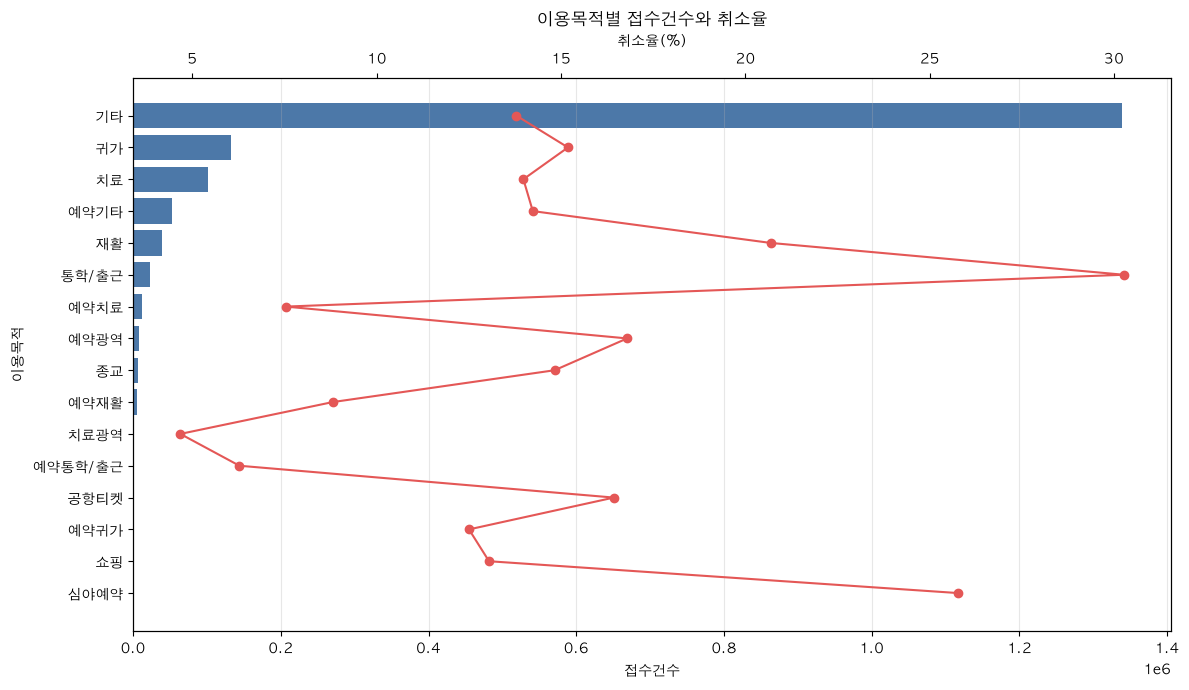

In [5]:
plot_data = purpose_demand_summary.sort_values('접수건수')
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.barh(plot_data['이용목적'], plot_data['접수건수'], color='#4c78a8')
ax1.set_xlabel('접수건수')
ax1.set_ylabel('이용목적')
ax1.grid(axis='x', alpha=0.3)

ax2 = ax1.twiny()
ax2.plot(plot_data['취소율(%)'], plot_data['이용목적'], color='#e45756', marker='o', label='취소율')
ax2.set_xlabel('취소율(%)')

plt.title('이용목적별 접수건수와 취소율')
plt.tight_layout()
plt.show()


## 차량구분별 접수→승차 시간 분포


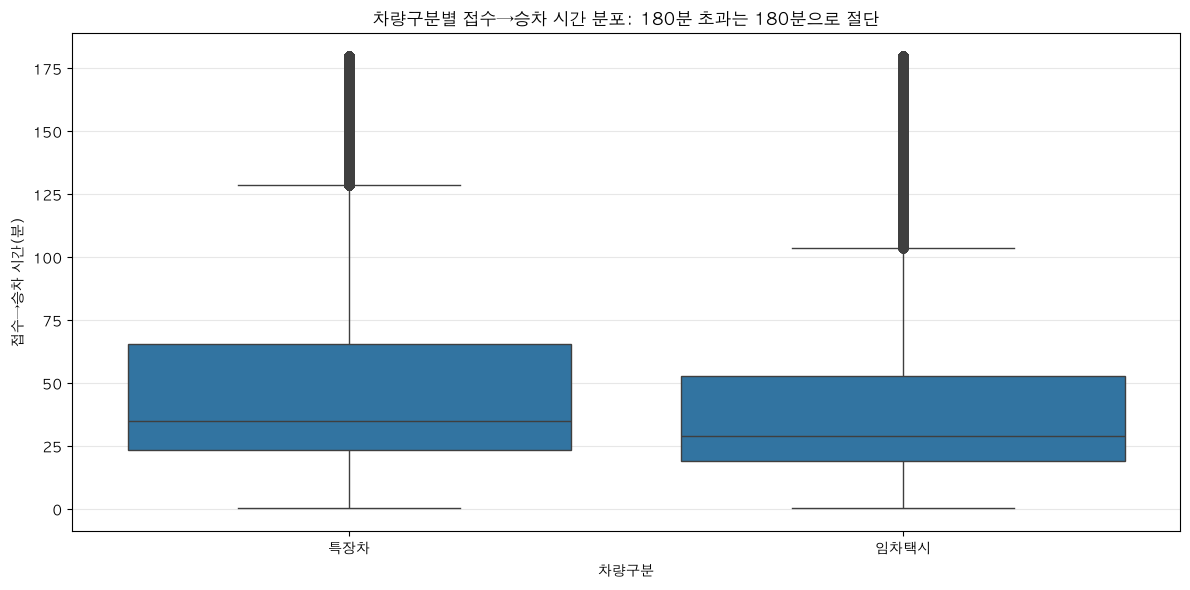

In [6]:
vehicle_order = vehicle_demand_summary.sort_values('접수건수', ascending=False)['차량구분']
plot_df = df_segment[df_segment['차량구분'].isin(vehicle_order)].dropna(subset=['접수_승차_분']).copy()
plot_df['접수_승차_분_clip'] = plot_df['접수_승차_분'].clip(upper=180)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x='차량구분',
    y='접수_승차_분_clip',
    order=vehicle_order
)
plt.title('차량구분별 접수→승차 시간 분포: 180분 초과는 180분으로 절단')
plt.xlabel('차량구분')
plt.ylabel('접수→승차 시간(분)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 장애유형별 접수건수와 취소율


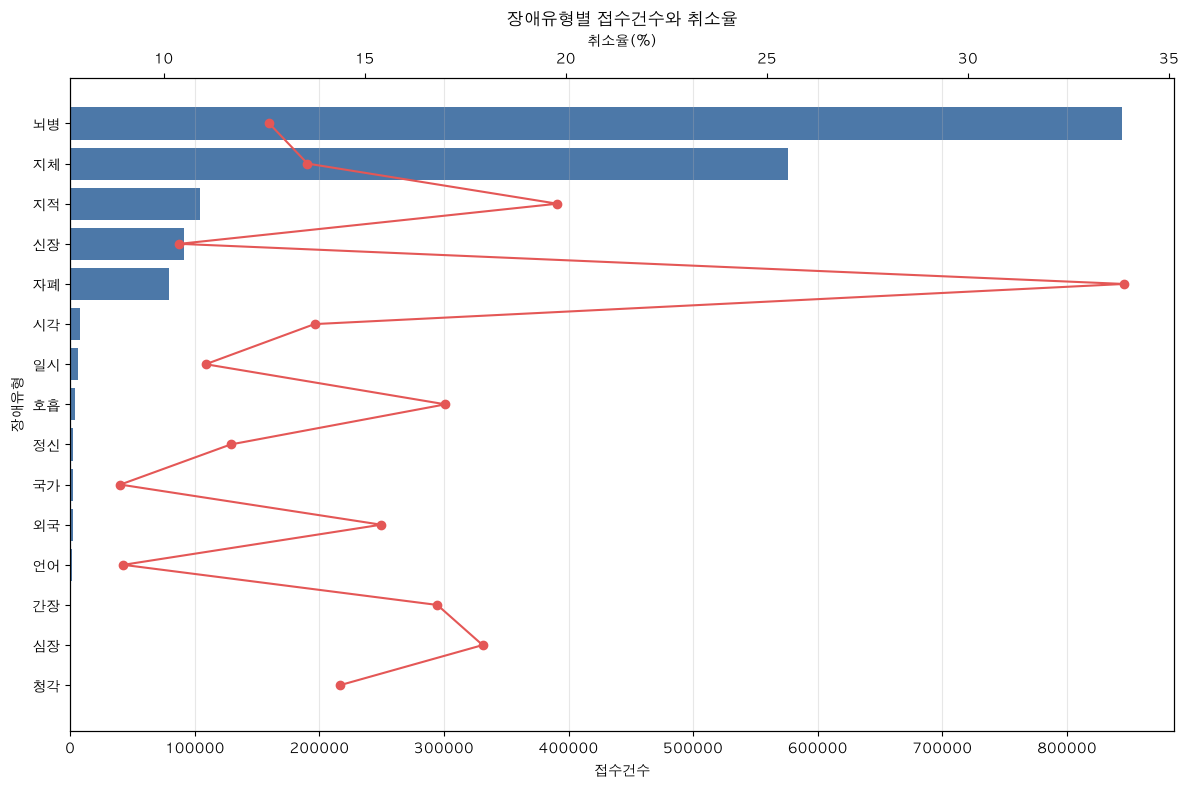

In [7]:
plot_data = disability_demand_summary.sort_values('접수건수')
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.barh(plot_data['장애유형'], plot_data['접수건수'], color='#4c78a8')
ax1.set_xlabel('접수건수')
ax1.set_ylabel('장애유형')
ax1.grid(axis='x', alpha=0.3)

ax2 = ax1.twiny()
ax2.plot(plot_data['취소율(%)'], plot_data['장애유형'], color='#e45756', marker='o', label='취소율')
ax2.set_xlabel('취소율(%)')

plt.title('장애유형별 접수건수와 취소율')
plt.tight_layout()
plt.show()


## 취소율/대기시간이 높은 세그먼트 후보


In [8]:
for name, summary in segment_demand_summary.items():
    print(f'{name}별 취소율 상위')
    display(summary.sort_values('취소율(%)', ascending=False).head(10))
    print(f'{name}별 평균 접수→승차 시간 상위')
    display(summary.sort_values('평균_접수승차분', ascending=False).head(10))


이용목적별 취소율 상위


,이용목적,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
5,통학/출근,23450,7097,16353,158.678385,158.524217,192.058020,30.264392,69.735608
15,심야예약,163,42,121,868.634538,875.075117,1091.627167,25.766871,74.233129
4,재활,38444,7950,30491,88.653295,72.407717,164.157400,20.679430,79.312767
7,예약광역,7338,1232,6105,1724.010537,1761.258283,2044.397770,16.789316,83.197056
12,공항티켓,420,69,351,140.716548,43.635283,127.518550,16.428571,83.571429
1,귀가,132585,20133,112449,61.779716,35.072450,151.667713,15.184976,84.812762
8,종교,6666,988,5678,46.441232,37.081750,89.715665,14.821482,85.178518
3,예약기타,52787,7512,45274,1390.732874,1457.770692,1473.663533,14.230777,85.767329
2,치료,101923,14244,87674,67.639971,43.052608,154.376498,13.975256,86.019839
0,기타,1338521,184484,1153988,40.039708,31.186833,78.814555,13.782675,86.213664


이용목적별 평균 접수→승차 시간 상위


,이용목적,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
7,예약광역,7338,1232,6105,1724.010537,1761.258283,2044.397770,16.789316,83.197056
11,예약통학/출근,1594,100,1494,1431.411574,1460.025392,1473.515483,6.273526,93.726474
9,예약재활,4646,409,4236,1397.418931,1457.588000,1471.578308,8.803272,91.175204
3,예약기타,52787,7512,45274,1390.732874,1457.770692,1473.663533,14.230777,85.767329
6,예약치료,11741,884,10856,1364.277044,1453.384142,1469.374858,7.529171,92.462312
14,예약귀가,184,23,161,1241.871064,1334.680050,1473.361117,12.500000,87.500000
15,심야예약,163,42,121,868.634538,875.075117,1091.627167,25.766871,74.233129
10,치료광역,1777,83,1694,372.123569,52.868000,1451.264563,4.670793,95.329207
5,통학/출근,23450,7097,16353,158.678385,158.524217,192.058020,30.264392,69.735608
12,공항티켓,420,69,351,140.716548,43.635283,127.518550,16.428571,83.571429


차량구분별 취소율 상위


...

,차량구분,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
0,특장차,1393551,228996,1164491,120.107156,35.117000,138.228500,16.432553,83.562855
1,임차택시,328880,16279,312601,70.792694,29.068333,102.328217,4.949830,95.050170


장애유형별 취소율 상위


,장애유형,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
4,자폐,79014,26770,52244,54.570283,33.808025,97.077165,33.880072,66.119928
2,지적,103840,20550,83288,55.124177,34.306475,96.406602,19.790062,80.208012
13,심장,329,59,270,84.447798,32.880775,93.391040,17.933131,82.066869
7,호흡,3904,664,3240,58.768954,32.718192,113.790993,17.008197,82.991803
12,간장,595,100,494,43.935551,28.443750,74.606917,16.806723,83.025210
10,외국,2109,325,1784,50.619484,37.426967,93.272162,15.410147,84.589853
14,청각,285,41,244,33.878035,26.866783,66.285265,14.385965,85.614035
5,시각,7525,1035,6490,47.089681,30.474700,86.423755,13.754153,86.245847
1,지체,575928,78205,497708,130.545421,34.267358,140.890872,13.578954,86.418441
0,뇌병,843997,106579,737373,112.749349,33.576667,137.068923,12.627888,87.366780


장애유형별 평균 접수→승차 시간 상위


,장애유형,접수건수,취소건수,탑승건수,평균_접수승차분,중앙값_접수승차분,p90_접수승차분,취소율(%),탑승전환율(%)
1,지체,575928,78205,497708,130.545421,34.267358,140.890872,13.578954,86.418441
0,뇌병,843997,106579,737373,112.749349,33.576667,137.068923,12.627888,87.366780
9,국가,2442,218,2224,95.493287,34.191192,153.886668,8.927109,91.072891
13,심장,329,59,270,84.447798,32.880775,93.391040,17.933131,82.066869
3,신장,91602,9524,82077,62.958296,33.477933,144.839020,10.397153,89.601755
7,호흡,3904,664,3240,58.768954,32.718192,113.790993,17.008197,82.991803
2,지적,103840,20550,83288,55.124177,34.306475,96.406602,19.790062,80.208012
4,자폐,79014,26770,52244,54.570283,33.808025,97.077165,33.880072,66.119928
10,외국,2109,325,1784,50.619484,37.426967,93.272162,15.410147,84.589853
8,정신,2485,290,2195,47.923742,28.636950,102.240550,11.670020,88.329980
